# RAG Pipeline Comparison: Manual vs LangChain

This notebook systematically compares two RAG pipelines on 30 KDK test questions:
- **Manual pipeline**: `##`-based chunking + sentence-transformers (`all-MiniLM-L6-v2`, 384d) + Qdrant + Ollama
- **LangChain pipeline**: `RecursiveCharacterTextSplitter` + Ollama embeddings (`nomic-embed-text`, 768d) + LangChain Qdrant + ChatOllama

**Sections:**
1. Configuration & Initialization
2. Chunking Strategy Comparison
3. Vectorization & Ingestion
4. Pipeline Execution
5. LLM-as-Judge Scoring
6. DataFrame Assembly
7. Visualization (7 charts + 1 HTML table)
8. Summary & Statistical Tests

---
## Section 1: Configuration & Initialization

In [1]:
import json
import re
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.auto import tqdm
import requests

from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from IPython.display import display, HTML

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120

print("All imports OK")

All imports OK


In [2]:
# ── Constants ──
ROOT_DIR = Path("..").resolve()
DOCS_DIR = ROOT_DIR / "data" / "kdk" / "docs"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
OLLAMA_URL = "http://localhost:11434"
OLLAMA_MODEL = "qwen2.5:7b"

# Dedicated collections for evaluation (won't touch md_chunks_demo)
MANUAL_COLLECTION = "manual_rag_eval"
LANGCHAIN_COLLECTION = "langchain_rag_eval"

MANUAL_EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 384d
LANGCHAIN_EMBEDDING_MODEL = "nomic-embed-text"  # 768d via Ollama

TOP_K = 5

print(f"Docs dir: {DOCS_DIR} (exists={DOCS_DIR.exists()})")
print(f"Qdrant:   {QDRANT_URL}")
print(f"Ollama:   {OLLAMA_URL} / model={OLLAMA_MODEL}")

Docs dir: D:\kalisio\code_rag\data\kdk\docs (exists=True)
Qdrant:   http://localhost:6333
Ollama:   http://localhost:11434 / model=qwen2.5:7b


In [3]:
# ── Parse test_questions_en.md ──
def parse_test_questions(path: Path) -> list[dict]:
    text = path.read_text(encoding="utf-8")
    questions = []
    current_difficulty = "Unknown"
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("## "):
            current_difficulty = line[3:].strip()
        match = re.match(r"^(\d+)\.\s+(.+)$", line)
        if match:
            questions.append({
                "id": int(match.group(1)),
                "difficulty": current_difficulty,
                "question": match.group(2),
            })
    return questions

questions = parse_test_questions(ROOT_DIR / "test_questions_en.md")
print(f"Loaded {len(questions)} questions")
for q in questions[:3]:
    print(f"  [{q['id']}] ({q['difficulty']}) {q['question']}")

Loaded 30 questions
  [1] (Easy) What does KDK stand for?
  [2] (Easy) What is the main goal of the Kalisio Development Kit?
  [3] (Easy) What kind of applications is KDK designed to help build?


---
## Section 2: Chunking Strategy Comparison

In [4]:
# ── Manual chunking: split on "## " (replicates src/chunk_md.py logic) ──
def chunk_md_manual(docs_dir: Path) -> list[dict]:
    """In-memory version of step6_process_all_and_save."""
    md_files = sorted(docs_dir.rglob("*.md"))
    all_chunks = []
    for filepath in md_files:
        text = filepath.read_text(encoding="utf-8")
        lines = text.splitlines()
        rel_path = str(filepath.relative_to(docs_dir))

        # Extract H1 as doc_title
        doc_title = filepath.stem
        for line in lines:
            if line.startswith("# ") and not line.startswith("## "):
                doc_title = line[2:].strip()
                break

        current_title = doc_title
        current_lines = []

        for line in lines:
            if line.startswith("## "):
                if current_lines:
                    all_chunks.append({
                        "text": "\n".join(current_lines).strip(),
                        "metadata": {
                            "source": rel_path,
                            "doc_title": doc_title,
                            "section_title": current_title,
                        },
                    })
                current_title = line[3:].strip()
                current_lines = [line]
            else:
                current_lines.append(line)

        if current_lines:
            all_chunks.append({
                "text": "\n".join(current_lines).strip(),
                "metadata": {
                    "source": rel_path,
                    "doc_title": doc_title,
                    "section_title": current_title,
                },
            })
    return all_chunks

manual_chunks = chunk_md_manual(DOCS_DIR)
print(f"Manual chunks: {len(manual_chunks)}")

Manual chunks: 642


In [5]:
# ── LangChain chunking: RecursiveCharacterTextSplitter ──
def chunk_md_langchain(docs_dir: Path) -> list[Document]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        separators=["\n## ", "\n### ", "\n\n", "\n", " "],
    )
    documents = []
    md_files = sorted(docs_dir.rglob("*.md"))
    for filepath in md_files:
        text = filepath.read_text(encoding="utf-8")
        rel_path = str(filepath.relative_to(docs_dir))
        # Extract H1 as doc_title
        doc_title = filepath.stem
        for line in text.splitlines():
            if line.startswith("# ") and not line.startswith("## "):
                doc_title = line[2:].strip()
                break
        docs = splitter.create_documents(
            texts=[text],
            metadatas=[{"source": rel_path, "doc_title": doc_title}],
        )
        documents.extend(docs)
    return documents

langchain_docs = chunk_md_langchain(DOCS_DIR)
print(f"LangChain chunks: {len(langchain_docs)}")

LangChain chunks: 873


In [6]:
# ── Chunking statistics comparison ──
manual_lengths = [len(c["text"]) for c in manual_chunks]
lc_lengths = [len(d.page_content) for d in langchain_docs]

stats = pd.DataFrame({
    "Metric": ["Total chunks", "Mean length", "Median length", "Max length", "Min length"],
    "Manual (## split)": [
        len(manual_lengths),
        f"{np.mean(manual_lengths):.0f}",
        f"{np.median(manual_lengths):.0f}",
        max(manual_lengths),
        min(manual_lengths),
    ],
    "LangChain (RCT 1000/200)": [
        len(lc_lengths),
        f"{np.mean(lc_lengths):.0f}",
        f"{np.median(lc_lengths):.0f}",
        max(lc_lengths),
        min(lc_lengths),
    ],
})
display(stats)

,Metric,Manual (## split),LangChain (RCT 1000/200)
0,Total chunks,642,873
1,Mean length,788,604
2,Median length,287,660
3,Max length,11924,999
4,Min length,5,3


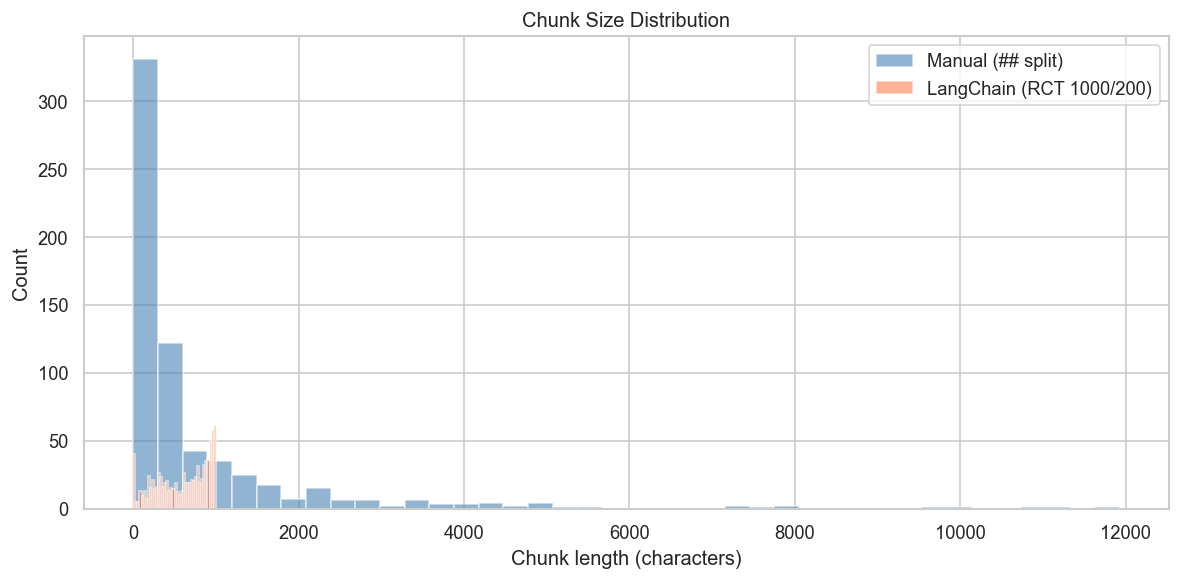

In [7]:
# ── Visualization: chunk size distribution histogram ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(manual_lengths, bins=40, alpha=0.6, label="Manual (## split)", color="steelblue")
ax.hist(lc_lengths, bins=40, alpha=0.6, label="LangChain (RCT 1000/200)", color="coral")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3: Vectorization & Ingestion

In [8]:
# ── Manual pipeline: sentence-transformers batch encode → Qdrant ──
st_model = SentenceTransformer(MANUAL_EMBEDDING_MODEL)

print("Encoding manual chunks...")
manual_texts = [c["text"] for c in manual_chunks]
manual_vectors = st_model.encode(manual_texts, show_progress_bar=True, batch_size=64)
print(f"Encoded {len(manual_vectors)} vectors of dim {manual_vectors.shape[1]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding manual chunks...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Encoded 642 vectors of dim 384


In [9]:
# ── Upsert manual vectors into Qdrant ──
qdrant = QdrantClient(url=QDRANT_URL)

if qdrant.collection_exists(MANUAL_COLLECTION):
    qdrant.delete_collection(MANUAL_COLLECTION)

qdrant.create_collection(
    collection_name=MANUAL_COLLECTION,
    vectors_config=VectorParams(size=manual_vectors.shape[1], distance=Distance.COSINE),
)

points = [
    PointStruct(
        id=i,
        vector=manual_vectors[i].tolist(),
        payload={"text": manual_chunks[i]["text"], **manual_chunks[i]["metadata"]},
    )
    for i in range(len(manual_chunks))
]
qdrant.upsert(collection_name=MANUAL_COLLECTION, points=points)

info = qdrant.get_collection(MANUAL_COLLECTION)
print(f"Collection '{MANUAL_COLLECTION}': {info.points_count} points")

Collection 'manual_rag_eval': 642 points


In [10]:
# ── LangChain pipeline: Ollama embeddings → Qdrant via langchain-qdrant ──
lc_embeddings = OllamaEmbeddings(
    model=LANGCHAIN_EMBEDDING_MODEL,
    base_url=OLLAMA_URL,
)

# Delete existing collection if present
if qdrant.collection_exists(LANGCHAIN_COLLECTION):
    qdrant.delete_collection(LANGCHAIN_COLLECTION)

print(f"Ingesting {len(langchain_docs)} LangChain docs (this may take several minutes)...")
lc_vectorstore = QdrantVectorStore.from_documents(
    documents=langchain_docs,
    embedding=lc_embeddings,
    url=QDRANT_URL,
    collection_name=LANGCHAIN_COLLECTION,
)

info = qdrant.get_collection(LANGCHAIN_COLLECTION)
print(f"Collection '{LANGCHAIN_COLLECTION}': {info.points_count} points")

Ingesting 873 LangChain docs (this may take several minutes)...
Collection 'langchain_rag_eval': 873 points


---
## Section 4: Pipeline Execution

In [11]:
# ── Shared prompt template (same semantics for both pipelines) ──
SYSTEM_PROMPT = (
    "You are a helpful assistant.\n"
    "Answer the user's question only from the provided context.\n"
    "If the answer is not in the context, say you do not know."
)

def format_prompt(question: str, context: str) -> str:
    return (
        f"{SYSTEM_PROMPT}\n\n"
        f"Context:\n{context}\n\n"
        f"Question:\n{question}\n\n"
        "Answer:"
    )

In [12]:
# ── Manual RAG pipeline ──
def run_manual_pipeline(question: str) -> dict:
    # Retrieval
    t0 = time.time()
    query_vector = st_model.encode(question).tolist()
    results = qdrant.query_points(
        collection_name=MANUAL_COLLECTION,
        query=query_vector,
        limit=TOP_K,
        with_payload=True,
    )
    retrieval_time = time.time() - t0

    # Build context
    chunks_info = []
    context_parts = []
    for idx, point in enumerate(results.points, 1):
        payload = point.payload or {}
        text = payload.get("text", "")
        source = payload.get("source", "")
        section = payload.get("section_title", "")
        context_parts.append(
            f"[Chunk {idx}]\nSource: {source}\nSection: {section}\nContent:\n{text}"
        )
        chunks_info.append({
            "source": source,
            "section_title": section,
            "score": point.score,
            "text_preview": text[:200],
        })

    context = "\n\n".join(context_parts)
    prompt = format_prompt(question, context)

    # Generation
    t1 = time.time()
    resp = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={"model": OLLAMA_MODEL, "prompt": prompt, "stream": False},
        timeout=120,
    )
    resp.raise_for_status()
    answer = resp.json().get("response", "").strip()
    generation_time = time.time() - t1

    return {
        "answer": answer,
        "chunks": chunks_info,
        "context": context,
        "retrieval_time": retrieval_time,
        "generation_time": generation_time,
    }

In [13]:
# ── LangChain RAG pipeline ──
lc_chat = ChatOllama(model=OLLAMA_MODEL, base_url=OLLAMA_URL)

lc_prompt_template = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human", "Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"),
])

def run_langchain_pipeline(question: str) -> dict:
    # Retrieval
    t0 = time.time()
    results_with_scores = lc_vectorstore.similarity_search_with_score(
        question, k=TOP_K
    )
    retrieval_time = time.time() - t0

    # Build context
    chunks_info = []
    context_parts = []
    for idx, (doc, score) in enumerate(results_with_scores, 1):
        context_parts.append(
            f"[Chunk {idx}]\nSource: {doc.metadata.get('source', '')}\n"
            f"Content:\n{doc.page_content}"
        )
        chunks_info.append({
            "source": doc.metadata.get("source", ""),
            "score": score,
            "text_preview": doc.page_content[:200],
        })

    context = "\n\n".join(context_parts)

    # Generation
    t1 = time.time()
    messages = lc_prompt_template.format_messages(context=context, question=question)
    response = lc_chat.invoke(messages)
    answer = response.content.strip()
    generation_time = time.time() - t1

    return {
        "answer": answer,
        "chunks": chunks_info,
        "context": context,
        "retrieval_time": retrieval_time,
        "generation_time": generation_time,
    }

In [14]:
# ── Execute both pipelines on all 30 questions ──
RAW_RESULTS_PATH = OUTPUT_DIR / "comparison_raw_results.json"

# Support resuming: load existing results if available
if RAW_RESULTS_PATH.exists():
    with open(RAW_RESULTS_PATH, "r", encoding="utf-8") as f:
        all_results = json.load(f)
    print(f"Loaded {len(all_results)} existing results from cache")
else:
    all_results = []

done_ids = {(r["question_id"], r["pipeline"]) for r in all_results}

for q in tqdm(questions, desc="Running pipelines"):
    qid = q["id"]
    question_text = q["question"]

    for pipeline_name, run_fn in [("manual", run_manual_pipeline), ("langchain", run_langchain_pipeline)]:
        if (qid, pipeline_name) in done_ids:
            continue
        try:
            result = run_fn(question_text)
            all_results.append({
                "question_id": qid,
                "difficulty": q["difficulty"],
                "question": question_text,
                "pipeline": pipeline_name,
                "answer": result["answer"],
                "chunks": result["chunks"],
                "context": result["context"],
                "retrieval_time": result["retrieval_time"],
                "generation_time": result["generation_time"],
            })
        except Exception as e:
            print(f"  ERROR q{qid}/{pipeline_name}: {e}")
            all_results.append({
                "question_id": qid,
                "difficulty": q["difficulty"],
                "question": question_text,
                "pipeline": pipeline_name,
                "answer": f"ERROR: {e}",
                "chunks": [],
                "context": "",
                "retrieval_time": 0,
                "generation_time": 0,
            })

        # Checkpoint after each pipeline call
        with open(RAW_RESULTS_PATH, "w", encoding="utf-8") as f:
            json.dump(all_results, f, ensure_ascii=False, indent=2)

print(f"\nDone: {len(all_results)} total results saved to {RAW_RESULTS_PATH}")

Running pipelines:   0%|          | 0/30 [00:00<?, ?it/s]


Done: 60 total results saved to D:\kalisio\code_rag\outputs\comparison_raw_results.json


---
## Section 5: LLM-as-Judge Scoring

In [15]:
# ── Judge prompt ──
JUDGE_PROMPT_TEMPLATE = """You are an impartial evaluator. Score the following answer on three dimensions (1-5 each):

1. **Faithfulness**: Is the answer fully based on the provided context? (5 = entirely grounded, 1 = fabricated)
2. **Relevance**: Does the answer address the question? (5 = directly answers, 1 = off-topic)
3. **Completeness**: Does the answer cover all relevant information from the context? (5 = comprehensive, 1 = barely touches the topic)

Context:
{context}

Question:
{question}

Answer:
{answer}

Return ONLY a JSON object with keys "faithfulness", "relevance", "completeness", each an integer 1-5.
"""


def parse_judge_response(text: str) -> dict | None:
    """Try JSON parse first, then regex fallback."""
    # Try direct JSON parse
    try:
        obj = json.loads(text)
        if all(k in obj for k in ("faithfulness", "relevance", "completeness")):
            return {k: int(obj[k]) for k in ("faithfulness", "relevance", "completeness")}
    except (json.JSONDecodeError, ValueError):
        pass

    # Try extracting JSON from surrounding text
    match = re.search(r"\{[^}]+\}", text)
    if match:
        try:
            obj = json.loads(match.group())
            if all(k in obj for k in ("faithfulness", "relevance", "completeness")):
                return {k: int(obj[k]) for k in ("faithfulness", "relevance", "completeness")}
        except (json.JSONDecodeError, ValueError):
            pass

    # Regex fallback: look for key: value patterns
    scores = {}
    for key in ("faithfulness", "relevance", "completeness"):
        m = re.search(rf"{key}[\"\s:]+([1-5])", text, re.IGNORECASE)
        if m:
            scores[key] = int(m.group(1))
    if len(scores) == 3:
        return scores

    return None


def judge_answer(question: str, context: str, answer: str) -> dict:
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        context=context, question=question, answer=answer
    )
    resp = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False,
            "format": "json",
        },
        timeout=120,
    )
    resp.raise_for_status()
    raw = resp.json().get("response", "").strip()

    scores = parse_judge_response(raw)
    if scores is None:
        print(f"  WARNING: Could not parse judge response: {raw[:200]}")
        scores = {"faithfulness": 3, "relevance": 3, "completeness": 3}
    return scores

In [16]:
# ── Run judge on all results ──
JUDGED_RESULTS_PATH = OUTPUT_DIR / "comparison_judged_results.json"

# Support resuming
if JUDGED_RESULTS_PATH.exists():
    with open(JUDGED_RESULTS_PATH, "r", encoding="utf-8") as f:
        judged_results = json.load(f)
    print(f"Loaded {len(judged_results)} existing judged results")
else:
    judged_results = []

judged_ids = {(r["question_id"], r["pipeline"]) for r in judged_results}

for r in tqdm(all_results, desc="Judging answers"):
    if (r["question_id"], r["pipeline"]) in judged_ids:
        continue
    if r["answer"].startswith("ERROR:"):
        scores = {"faithfulness": 0, "relevance": 0, "completeness": 0}
    else:
        scores = judge_answer(r["question"], r["context"], r["answer"])

    judged_results.append({**r, **scores})

    # Checkpoint
    with open(JUDGED_RESULTS_PATH, "w", encoding="utf-8") as f:
        json.dump(judged_results, f, ensure_ascii=False, indent=2)

print(f"Done: {len(judged_results)} judged results saved to {JUDGED_RESULTS_PATH}")

Judging answers:   0%|          | 0/60 [00:00<?, ?it/s]

Done: 60 judged results saved to D:\kalisio\code_rag\outputs\comparison_judged_results.json


---
## Section 6: DataFrame Assembly

In [17]:
# ── Build DataFrame ──
df = pd.DataFrame(judged_results)

# Composite score = mean of 3 dimensions
df["composite_score"] = df[["faithfulness", "relevance", "completeness"]].mean(axis=1)

# Average retrieval score per row
df["avg_retrieval_score"] = df["chunks"].apply(
    lambda chunks: np.mean([c["score"] for c in chunks]) if chunks else 0
)

# Total time
df["total_time"] = df["retrieval_time"] + df["generation_time"]

print(f"DataFrame shape: {df.shape}")
display(df[["question_id", "difficulty", "pipeline", "faithfulness", "relevance",
            "completeness", "composite_score", "avg_retrieval_score",
            "retrieval_time", "generation_time"]].head(10))

DataFrame shape: (60, 15)


,question_id,difficulty,pipeline,faithfulness,relevance,completeness,composite_score,avg_retrieval_score,retrieval_time,generation_time
0,1,Easy,manual,3,2,1,2.000000,0.582274,0.044616,9.021753
1,1,Easy,langchain,2,1,1,1.333333,0.715774,2.580738,8.128924
2,2,Easy,manual,3,2,2,2.333333,0.518435,0.020316,2.561554
3,2,Easy,langchain,1,1,1,1.000000,0.634313,4.148199,8.724279
4,3,Easy,manual,4,5,3,4.000000,0.642388,0.020603,1.848636
5,3,Easy,langchain,5,5,5,5.000000,0.699577,2.484914,9.967011
6,4,Easy,manual,5,5,5,5.000000,0.477281,0.022700,1.855648
7,4,Easy,langchain,5,5,5,5.000000,0.582515,3.887417,10.269566
8,5,Easy,manual,5,5,5,5.000000,0.534437,0.024796,1.443831
9,5,Easy,langchain,5,5,5,5.000000,0.683535,4.228115,8.894620


In [18]:
# ── Compute chunk overlap (Jaccard similarity) between pipelines per question ──
def compute_chunk_overlap(judged_results: list[dict]) -> dict[int, float]:
    """For each question, compute Jaccard similarity of retrieved chunk sources."""
    by_question = {}
    for r in judged_results:
        qid = r["question_id"]
        pipeline = r["pipeline"]
        sources = set()
        for c in r.get("chunks", []):
            # Use source + text_preview as identifier
            sources.add(c.get("source", "") + "::" + c.get("text_preview", "")[:100])
        by_question.setdefault(qid, {})[pipeline] = sources

    overlaps = {}
    for qid, pipelines in by_question.items():
        s1 = pipelines.get("manual", set())
        s2 = pipelines.get("langchain", set())
        union = s1 | s2
        if union:
            overlaps[qid] = len(s1 & s2) / len(union)
        else:
            overlaps[qid] = 0.0
    return overlaps

chunk_overlaps = compute_chunk_overlap(judged_results)
df["chunk_overlap"] = df["question_id"].map(chunk_overlaps)

print(f"Mean chunk overlap (Jaccard): {np.mean(list(chunk_overlaps.values())):.3f}")

Mean chunk overlap (Jaccard): 0.091


In [19]:
# ── Save CSV ──
CSV_PATH = OUTPUT_DIR / "comparison_results.csv"
df_export = df.drop(columns=["chunks", "context"], errors="ignore")
df_export.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")
print(f"Saved {len(df_export)} rows to {CSV_PATH}")

Saved 60 rows to D:\kalisio\code_rag\outputs\comparison_results.csv


---
## Section 7: Visualization

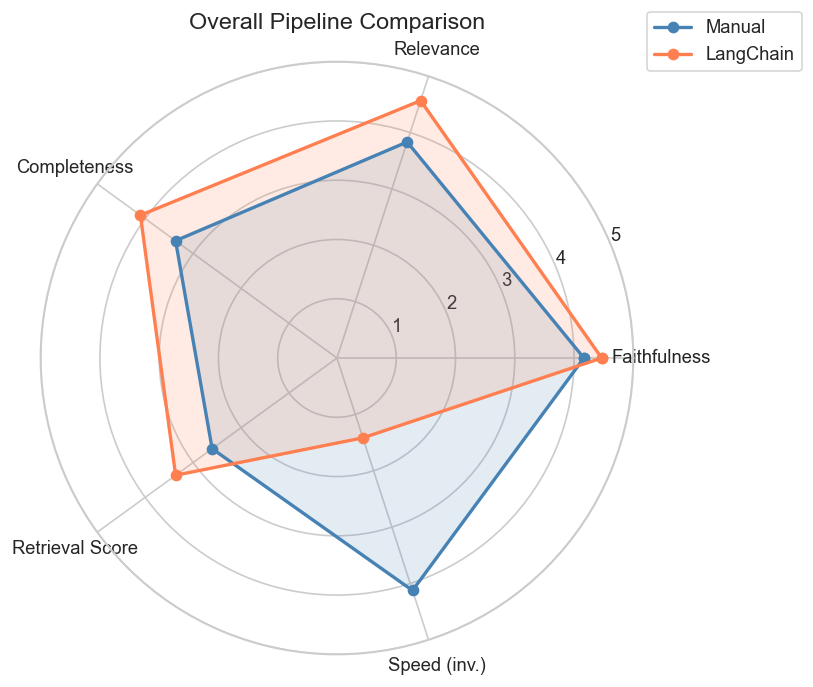

In [20]:
# ── Chart 1: Radar chart — overall dimension comparison ──
def radar_chart(df):
    categories = ["Faithfulness", "Relevance", "Completeness", "Retrieval Score", "Speed (inv.)"]
    n = len(categories)

    manual = df[df["pipeline"] == "manual"]
    lc = df[df["pipeline"] == "langchain"]

    # Normalize speed: invert so higher = faster, scale to 1-5
    max_time = df["total_time"].max()
    manual_speed = 5 * (1 - manual["total_time"].mean() / max_time) if max_time > 0 else 3
    lc_speed = 5 * (1 - lc["total_time"].mean() / max_time) if max_time > 0 else 3

    # Scale retrieval score to 1-5 range
    manual_ret = manual["avg_retrieval_score"].mean() * 5
    lc_ret = lc["avg_retrieval_score"].mean() * 5

    vals_manual = [
        manual["faithfulness"].mean(),
        manual["relevance"].mean(),
        manual["completeness"].mean(),
        manual_ret,
        manual_speed,
    ]
    vals_lc = [
        lc["faithfulness"].mean(),
        lc["relevance"].mean(),
        lc["completeness"].mean(),
        lc_ret,
        lc_speed,
    ]

    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    vals_manual += vals_manual[:1]
    vals_lc += vals_lc[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, vals_manual, "o-", linewidth=2, label="Manual", color="steelblue")
    ax.fill(angles, vals_manual, alpha=0.15, color="steelblue")
    ax.plot(angles, vals_lc, "o-", linewidth=2, label="LangChain", color="coral")
    ax.fill(angles, vals_lc, alpha=0.15, color="coral")
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0, 5)
    ax.set_title("Overall Pipeline Comparison", pad=20, fontsize=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

radar_chart(df)

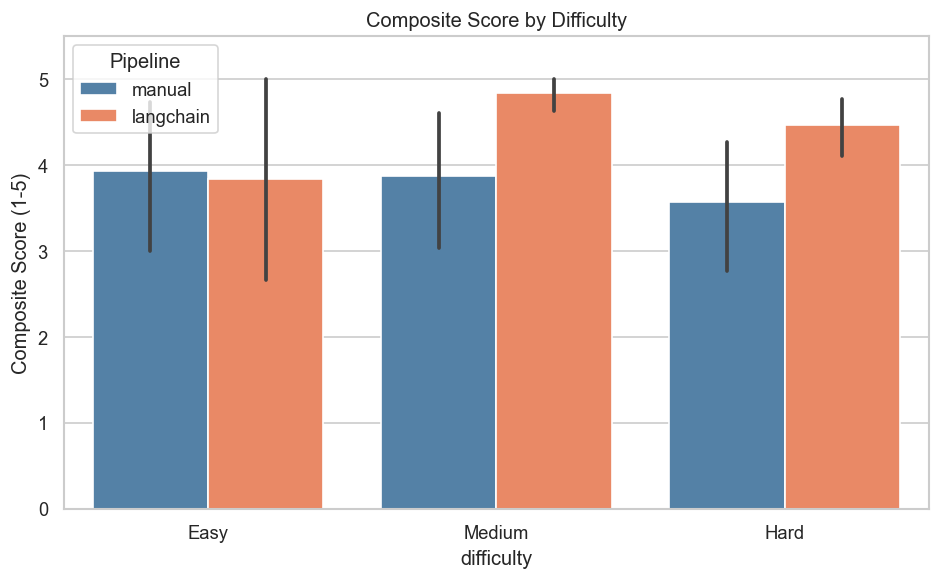

In [21]:
# ── Chart 2: Grouped bar chart — composite score by difficulty ──
fig, ax = plt.subplots(figsize=(8, 5))
difficulty_order = ["Easy", "Medium", "Hard"]
plot_df = df[df["difficulty"].isin(difficulty_order)].copy()
plot_df["difficulty"] = pd.Categorical(plot_df["difficulty"], categories=difficulty_order, ordered=True)

sns.barplot(
    data=plot_df, x="difficulty", y="composite_score", hue="pipeline",
    palette={"manual": "steelblue", "langchain": "coral"}, ax=ax,
)
ax.set_title("Composite Score by Difficulty")
ax.set_ylabel("Composite Score (1-5)")
ax.set_ylim(0, 5.5)
ax.legend(title="Pipeline")
plt.tight_layout()
plt.show()

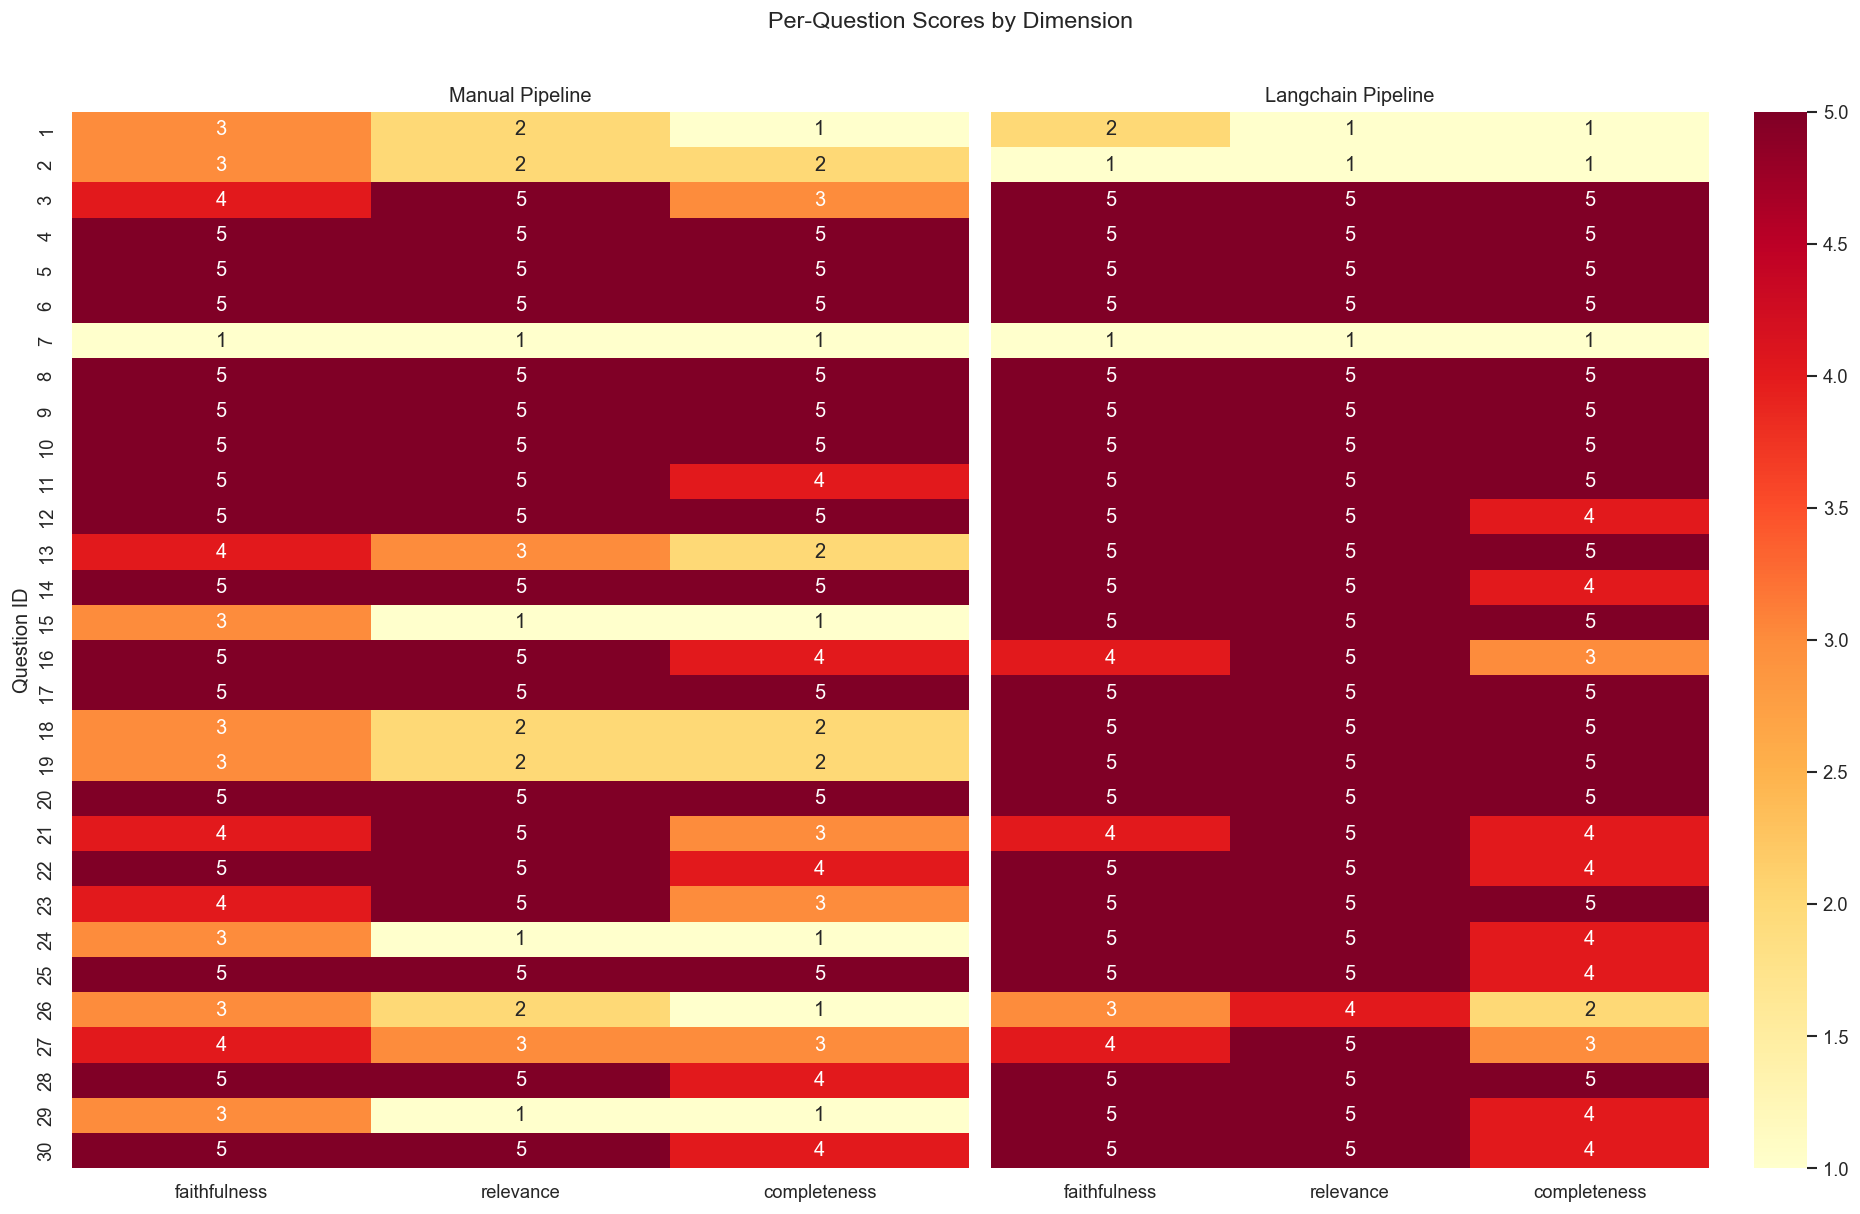

In [22]:
# ── Chart 3: Heatmaps — per-question scores for each pipeline ──
fig, axes = plt.subplots(1, 2, figsize=(16, 10), sharey=True)

for idx, (pipeline, ax) in enumerate(zip(["manual", "langchain"], axes)):
    sub = df[df["pipeline"] == pipeline].sort_values("question_id")
    heatmap_data = sub.set_index("question_id")[["faithfulness", "relevance", "completeness"]]
    sns.heatmap(
        heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", vmin=1, vmax=5,
        ax=ax, cbar=idx == 1,
    )
    ax.set_title(f"{pipeline.capitalize()} Pipeline")
    ax.set_ylabel("Question ID" if idx == 0 else "")

fig.suptitle("Per-Question Scores by Dimension", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\xiaos\AppData\Local\Temp\ipykernel_4196\2668315082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


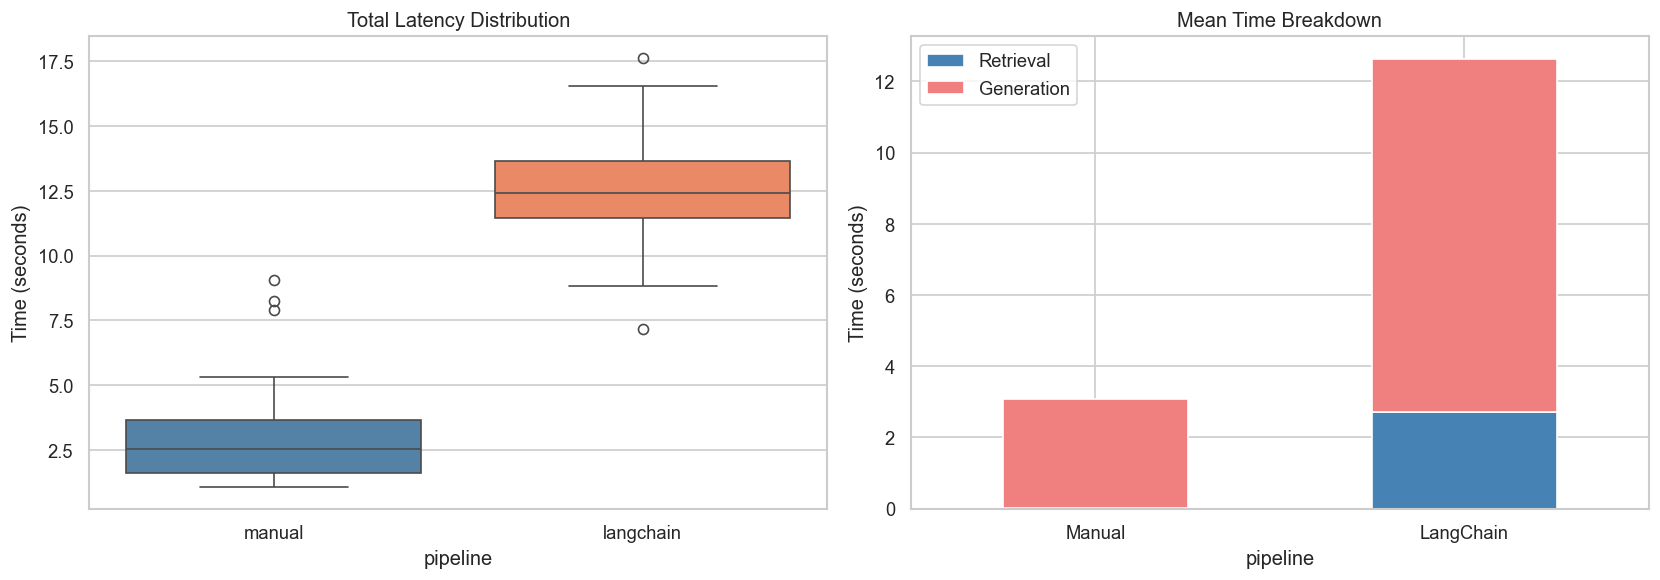

In [23]:
# ── Chart 4: Box plot — total latency + stacked bar for retrieval/generation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: total time
sns.boxplot(
    data=df, x="pipeline", y="total_time",
    palette={"manual": "steelblue", "langchain": "coral"}, ax=axes[0],
)
axes[0].set_title("Total Latency Distribution")
axes[0].set_ylabel("Time (seconds)")

# Stacked bar: mean retrieval + generation time
time_means = df.groupby("pipeline")[["retrieval_time", "generation_time"]].mean()
time_means = time_means.reindex(["manual", "langchain"])
time_means.plot.bar(
    stacked=True, color=["steelblue", "lightcoral"], ax=axes[1],
)
axes[1].set_title("Mean Time Breakdown")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_xticklabels(["Manual", "LangChain"], rotation=0)
axes[1].legend(["Retrieval", "Generation"])

plt.tight_layout()
plt.show()

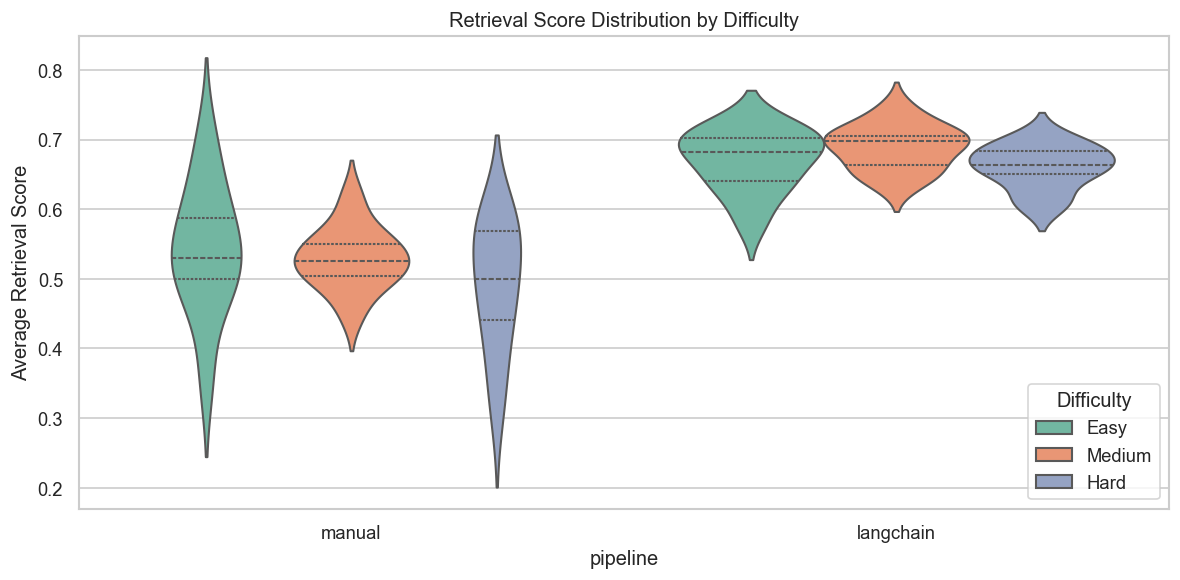

In [24]:
# ── Chart 5: Violin plot — retrieval score distribution by difficulty ──
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = df[df["difficulty"].isin(difficulty_order)].copy()
plot_df["difficulty"] = pd.Categorical(plot_df["difficulty"], categories=difficulty_order, ordered=True)

sns.violinplot(
    data=plot_df, x="pipeline", y="avg_retrieval_score", hue="difficulty",
    palette="Set2", inner="quart", ax=ax,
)
ax.set_title("Retrieval Score Distribution by Difficulty")
ax.set_ylabel("Average Retrieval Score")
ax.legend(title="Difficulty")
plt.tight_layout()
plt.show()

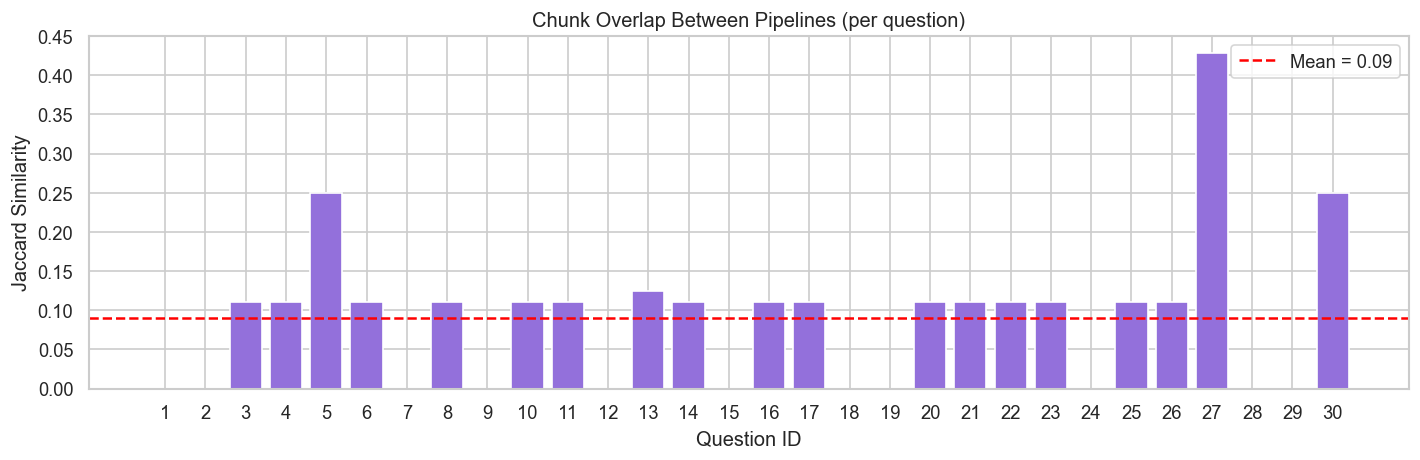

In [25]:
# ── Chart 6: Bar chart — Chunk overlap Jaccard per question ──
fig, ax = plt.subplots(figsize=(12, 4))
overlap_df = pd.DataFrame([
    {"question_id": qid, "jaccard": j}
    for qid, j in sorted(chunk_overlaps.items())
])
ax.bar(overlap_df["question_id"], overlap_df["jaccard"], color="mediumpurple")
ax.set_xlabel("Question ID")
ax.set_ylabel("Jaccard Similarity")
ax.set_title("Chunk Overlap Between Pipelines (per question)")
ax.set_xticks(overlap_df["question_id"])
ax.axhline(y=overlap_df["jaccard"].mean(), color="red", linestyle="--",
           label=f"Mean = {overlap_df['jaccard'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

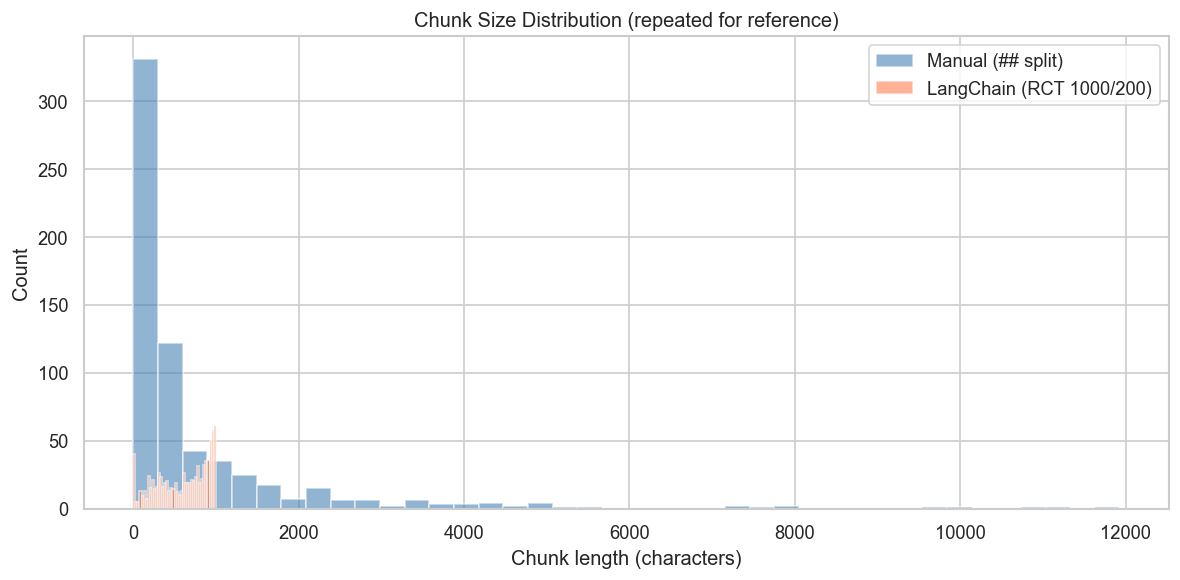

In [26]:
# ── Chart 7: Chunk size distribution (from Section 2) ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(manual_lengths, bins=40, alpha=0.6, label="Manual (## split)", color="steelblue")
ax.hist(lc_lengths, bins=40, alpha=0.6, label="LangChain (RCT 1000/200)", color="coral")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
ax.set_title("Chunk Size Distribution (repeated for reference)")
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# ── HTML Table: side-by-side comparison per question ──
def build_comparison_html(df):
    manual_df = df[df["pipeline"] == "manual"].set_index("question_id").sort_index()
    lc_df = df[df["pipeline"] == "langchain"].set_index("question_id").sort_index()

    rows = []
    for qid in sorted(df["question_id"].unique()):
        m = manual_df.loc[qid] if qid in manual_df.index else None
        l = lc_df.loc[qid] if qid in lc_df.index else None

        question = m["question"] if m is not None else (l["question"] if l is not None else "")
        difficulty = m["difficulty"] if m is not None else (l["difficulty"] if l is not None else "")

        m_answer = m["answer"][:300] + "..." if m is not None and len(m["answer"]) > 300 else (m["answer"] if m is not None else "N/A")
        l_answer = l["answer"][:300] + "..." if l is not None and len(l["answer"]) > 300 else (l["answer"] if l is not None else "N/A")

        m_score = f"{m['composite_score']:.1f}" if m is not None else "N/A"
        l_score = f"{l['composite_score']:.1f}" if l is not None else "N/A"

        # Color: green for winner, red for loser
        m_cs = m["composite_score"] if m is not None else 0
        l_cs = l["composite_score"] if l is not None else 0
        m_color = "#d4edda" if m_cs > l_cs else ("#f8d7da" if m_cs < l_cs else "#fff3cd")
        l_color = "#d4edda" if l_cs > m_cs else ("#f8d7da" if l_cs < m_cs else "#fff3cd")

        rows.append(f"""
        <tr>
            <td style="font-weight:bold;">{qid}</td>
            <td><b>[{difficulty}]</b> {question}</td>
            <td style="background:{m_color}; font-size:0.85em;">{m_answer}</td>
            <td style="background:{m_color}; text-align:center; font-weight:bold;">{m_score}</td>
            <td style="background:{l_color}; font-size:0.85em;">{l_answer}</td>
            <td style="background:{l_color}; text-align:center; font-weight:bold;">{l_score}</td>
        </tr>""")

    html = f"""
    <h3>Side-by-Side Comparison</h3>
    <table style="border-collapse: collapse; width: 100%; font-size: 0.9em;">
    <thead>
        <tr style="background: #343a40; color: white;">
            <th style="padding:8px; width:3%;">ID</th>
            <th style="padding:8px; width:22%;">Question</th>
            <th style="padding:8px; width:30%;">Manual Answer</th>
            <th style="padding:8px; width:5%;">Score</th>
            <th style="padding:8px; width:30%;">LangChain Answer</th>
            <th style="padding:8px; width:5%;">Score</th>
        </tr>
    </thead>
    <tbody>
        {''.join(rows)}
    </tbody>
    </table>
    <p style="font-size:0.8em; color:#666;">Green = winner, Red = loser, Yellow = tie</p>
    """
    return html

display(HTML(build_comparison_html(df)))

ID,Question,Manual Answer,Score,LangChain Answer,Score
1,[Easy] What does KDK stand for?,I do not know. The provided context does not include an acronym explanation for KDK.,2.0,I do not know.,1.3
2,[Easy] What is the main goal of the Kalisio Development Kit?,"The main goal of the Kalisio Development Kit (KDK) is not explicitly stated in the provided context. However, based on the information given, KDK appears to be a development kit offered by Kalisio, designed for developers to use. For more detailed information about its purpose and features, you migh...",2.3,"The information provided does not contain any details about the Kalisio Development Kit or its main goals. Therefore, I do not know.",1.0
3,[Easy] What kind of applications is KDK designed to help build?,"KDK (Kalisio Development Kit) is designed to help build apps using a thin layer on top of the FeathersJS application, mainly to simplify the creation and configuration of services. It also provides helpful concepts and utilities to structure your application.",4.0,"KDK is designed to help build geospatial web applications running on desktop or mobile devices, with a focus on simplifying the development process. It is particularly useful for building multitenancy applications provided as SaaS (cloud-based) solutions, but it can also be used to build legacy appl...",5.0
4,[Easy] Where can users join the Kalisio community chat?,Users can join the Kalisio community chat by using the invitation link at https://join.slack.com/t/kalisio/shared_invite/zt-mfyu6evk-ehKFK7wSle4lX9imk5huew.,5.0,"Users can join the Kalisio community chat by using the invitation link provided in the slack channel, which can be accessed via this [invitation link](https://join.slack.com/t/kalisio/shared_invite/zt-mfyu6evk-ehKFK7wSle4lX9imk5huew).",5.0
5,[Easy] Under which NPM namespace are KDK modules published?,KDK modules are published under the `@kalisio` namespace in NPM.,5.0,Kalisio maintained modules are published under the `@kalisio` namespace in NPM.,5.0
6,[Easy] What are the three main API parts of a KDK submodule?,The three main API parts of a KDK submodule are: - client API (`client` folder in submodule folder) to be used within the browser and imported like this: `import { xxx } from '@kalisio/kdk/core.client'` - common API (`common` folder in submodule folder) to be used within the browser or NodeJS an...,5.0,The three main API parts of a KDK submodule are: - client API (`client` folder in submodule folder) to be used within the browser and imported like this: `import { xxx } from '@kalisio/kdk/core.client'` - common API (`common` folder in submodule folder) to be used within the browser or NodeJS and...,5.0
7,[Easy] What license is used by KDK?,I do not know. The provided context does not contain information about the license used by KDK.,1.0,I do not know.,1.0
8,[Easy] Where can contributors report a bug for KDK?,Contributors can report a bug for KDK in the [issue tracker](https://github.com/kalisio/kdk/issues).,5.0,Contributors can report a bug for KDK in the [issue tracker](https://github.com/kalisio/kdk/issues).,5.0
9,[Easy] What does the Guides section help developers learn?,"The Guides section helps developers learn how to set up their development environment, create, develop, and publish their own apps and modules, which also includes how to develop the KDK.",5.0,"The Guides section helps developers learn more about the underlying technological stack and how to deploy their first KDK app, as well as step-by-step how to setup their development environment, create, develop, test, publish their own app and modules, configure their app, and deploy their app.",5.0
10,[Easy] What is shown in the KDK global architecture overview?,The KDK global architecture overview shows a diagram summarizing the typical global architecture and underlying technologies of KDK.,5.0,The typical global architecture and the underlying technologies of KDK are summarized in a diagram.,5.0


---
## Section 8: Summary & Statistical Tests

In [28]:
# ── Aggregate statistics ──
summary = df.groupby("pipeline").agg({
    "faithfulness": "mean",
    "relevance": "mean",
    "completeness": "mean",
    "composite_score": "mean",
    "avg_retrieval_score": "mean",
    "retrieval_time": "mean",
    "generation_time": "mean",
    "total_time": "mean",
}).round(3)

print("=== Aggregate Statistics ===")
display(summary)

=== Aggregate Statistics ===


,faithfulness,relevance,completeness,composite_score,avg_retrieval_score,retrieval_time,generation_time,total_time
pipeline,,,,,,,,
langchain,4.467,4.567,4.100,4.378,0.673,2.705,9.935,12.640
manual,4.167,3.833,3.367,3.789,0.521,0.026,3.062,3.089


In [29]:
# ── Win / Tie / Loss count ──
manual_scores = df[df["pipeline"] == "manual"].sort_values("question_id")["composite_score"].values
lc_scores = df[df["pipeline"] == "langchain"].sort_values("question_id")["composite_score"].values

wins = int(np.sum(manual_scores > lc_scores))
ties = int(np.sum(manual_scores == lc_scores))
losses = int(np.sum(manual_scores < lc_scores))

print(f"Manual vs LangChain (per question):")
print(f"  Manual wins:  {wins}")
print(f"  Ties:         {ties}")
print(f"  LangChain wins: {losses}")

Manual vs LangChain (per question):
  Manual wins:  6
  Ties:         11
  LangChain wins: 13


In [30]:
# ── Wilcoxon signed-rank test ──
from scipy.stats import wilcoxon

diff = manual_scores - lc_scores
# Wilcoxon requires at least one non-zero difference
if np.any(diff != 0):
    stat, p_value = wilcoxon(diff)
    print(f"Wilcoxon signed-rank test:")
    print(f"  Statistic: {stat:.2f}")
    print(f"  p-value:   {p_value:.4f}")
    if p_value < 0.05:
        winner = "Manual" if np.mean(diff) > 0 else "LangChain"
        print(f"  => Statistically significant difference (p < 0.05). {winner} pipeline is better.")
    else:
        print(f"  => No statistically significant difference (p >= 0.05).")
else:
    print("All scores are identical — no statistical test needed.")

Wilcoxon signed-rank test:
  Statistic: 40.50
  p-value:   0.0276
  => Statistically significant difference (p < 0.05). LangChain pipeline is better.


### Conclusions

Key findings from this comparison:

1. **Chunking**: Manual `##`-based splitting produces variable-length chunks aligned with document structure, while LangChain's `RecursiveCharacterTextSplitter` produces more uniform chunks with controlled overlap.

2. **Embeddings**: `all-MiniLM-L6-v2` (384d, local) vs `nomic-embed-text` (768d, Ollama) — different models and dimensions are a key variable.

3. **Retrieval quality**: Check the heatmaps and violin plots above for per-question and per-difficulty breakdowns.

4. **Generation quality**: The LLM-as-Judge scores (faithfulness, relevance, completeness) reveal which pipeline provides better context for the same LLM to generate answers.

5. **Latency**: The time breakdown shows the cost of each approach — local sentence-transformers encoding is typically faster than Ollama API calls for embeddings.

6. **Chunk overlap**: Low Jaccard scores indicate the two pipelines retrieve substantially different content, which explains score differences.

Refer to the aggregate table, win/loss counts, and Wilcoxon test above for the final verdict.